# DNN: analysis with Keras of 2D data

# Keras Tuner 
check https://keras.io/keras_tuner/getting_started/ or just pip install keras-tuner -q 

install tensorflow 


In [17]:
!pip install tensorflow

  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [12]:
!pip install keras-tuner -q

In [155]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras_tuner

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py #file with functions

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

## Read data

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


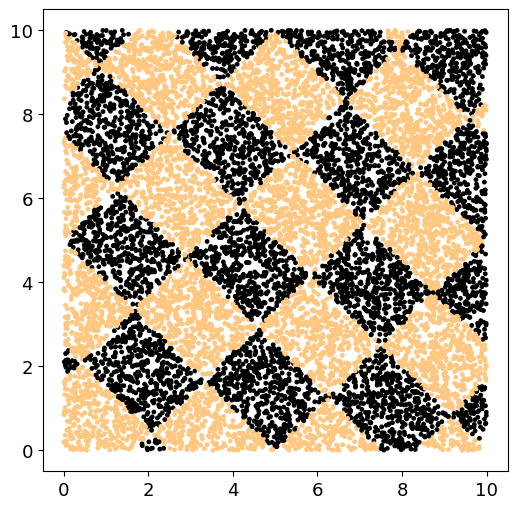

In [147]:
# Keras works with numpy arrays: just use them from the start
#type of non linear fucntion used
TYPE=4
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')
#generates the splitting configuration of the database
plot_data(x,y)

## Split data and standardize (fit on train only)

In [149]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss
    #shifts all the values by their mean and divide by std -> mean value go to 0 and std go to 1
#standardize the data is the first step, defining a standardize function -> the train dataset is standardized by itself

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
train stats before rescaling:
mean value= [5.04383556 5.03143184 5.03638185 4.99123028 5.00918736 4.99471823
 4.9375672  5.01176141] 
std. dev.= [2.88308918 2.91115484 2.91251069 2.88325032 2.88649055 2.87804296
 2.894575   2.88443829]
validation stats before rescaling:
mean value= [5.01414009 5.00920934 4.91969041 5.11954114 5.06362845 4.91602822
 5.02241381 5.00356572] 
std. dev.= [2.87232225 2.93790825 2.89202972 2.92071026 2.8993163  2.85120793
 2.86762585 2.87656225]
test stats before rescaling:
mean value= [5.06130124 4.97546115 4.98486276 5.00189652 4.91668817 5.01038162
 4.90755073 5.05680129] 
std. dev.= [2.89916908 2.87260102 2.91210833 2.85954228 2.90278174 2.88699779
 2.8850836  2.85815628]
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


## Define the model with Keras / Tensorflow

In [151]:
# reproducibility (?)
#three types of newral networks (all feedforward)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

# We use case 1
CASE=1 #exercicio: case 1 use 3 layers with 20 units
#building the neural network (layers -> neurons, etc)
if CASE==1:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu')) #input layer
    model.add(Dense(20,activation='relu')) #3hidden layers, with 20 neurons
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.05))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.05))
    model.add(Dense(1,activation='sigmoid')) #to output a probability (in the state 0 or 1)
    nepoch=200
# as case 1 but one layer shorter
#dropout meuron - prob of the neuron and its connections not being there (avoids overfitting by adding a bit noise)
if CASE==2:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(40,activation='relu')) #dense layers = all to all connectivity
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
#deeper
if CASE==3:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
    
print(model.summary())
#shows the amount of parameters in your NN
#New parameters - weight and bias each layer
#to count the parameters in NN -> INPUT UNITS * OUTPUT UNITS + OUTPUT UNITS
#To choose a model: the #total parameters < #training sample otherwise its overfitting

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                     │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 20)                  │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [161]:
#initialize the tuner, we need to specify several arguments in the initializer.
tuner = keras_tuner.RandomSearch(
    hypermodel=model,
    objective="val_accuracy",
    max_trials=3,
    executions_per_trial=2,
    overwrite=True,
    directory="DATA",
    project_name="dnn_analise",
)
tuner.search_space_summary()


ValueError: Only input tensors may be passed as positional arguments. The following argument value should be passed as a keyword argument: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x00000236FECA54D0> (of type <class 'keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters'>)

In [157]:
# Get the top 2 models.
model = tuner.get_best_models(num_models=2)
best_model = model[0]
best_model.summary()


NameError: name 'tuner' is not defined

## Optimization method and cost function

In [135]:
model.compile(loss='binary_crossentropy',
              optimizer='RMSprop',
              #optimizer='adam',
              metrics=['accuracy'])
#accuracy = #correct predictions / #total predictions

## Training

In [ ]:
#sutdy whats the epoch, why / how input train and validations data
#splitting the data in batches -> larger batches, smoother the gradient (as opposed to smaller and noisier)

In [137]:
fit = model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
192/192 - 1s - 7ms/step - accuracy: 0.5086 - loss: 0.6954 - val_accuracy: 0.5125 - val_loss: 0.6907
Epoch 2/200
192/192 - 0s - 2ms/step - accuracy: 0.5106 - loss: 0.6929 - val_accuracy: 0.5300 - val_loss: 0.6901
Epoch 3/200
192/192 - 0s - 2ms/step - accuracy: 0.5205 - loss: 0.6916 - val_accuracy: 0.5392 - val_loss: 0.6900
Epoch 4/200
192/192 - 0s - 2ms/step - accuracy: 0.5282 - loss: 0.6899 - val_accuracy: 0.5383 - val_loss: 0.6887
Epoch 5/200
192/192 - 0s - 2ms/step - accuracy: 0.5256 - loss: 0.6906 - val_accuracy: 0.5367 - val_loss: 0.6892
Epoch 6/200
192/192 - 0s - 2ms/step - accuracy: 0.5341 - loss: 0.6888 - val_accuracy: 0.5308 - val_loss: 0.6886
Epoch 7/200
192/192 - 0s - 2ms/step - accuracy: 0.5334 - loss: 0.6884 - val_accuracy: 0.5392 - val_loss: 0.6889
Epoch 8/200
192/192 - 0s - 2ms/step - accuracy: 0.5346 - loss: 0.6875 - val_accuracy: 0.5275 - val_loss: 0.6889
Epoch 9/200
192/192 - 0s - 2ms/step - accuracy: 0.5373 - loss: 0.6867 - val_accuracy: 0.5358 - val_loss:

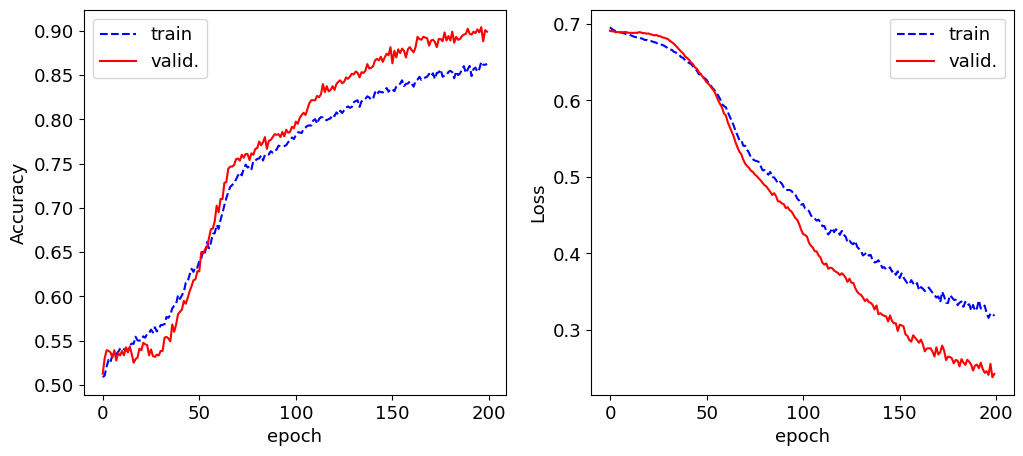

In [139]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

In [63]:
#algorithm -> loss function starting from 0.7 = very random (underfitting) and then working towards adjusting the loss and accuracy

# Evaluation on the test set


In [141]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")
#set the weights and the biases and then test the model
#inputing the test data 

Final test loss: 0.2747
Final test accuracy: 0.8858


## Grid to show preditions

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


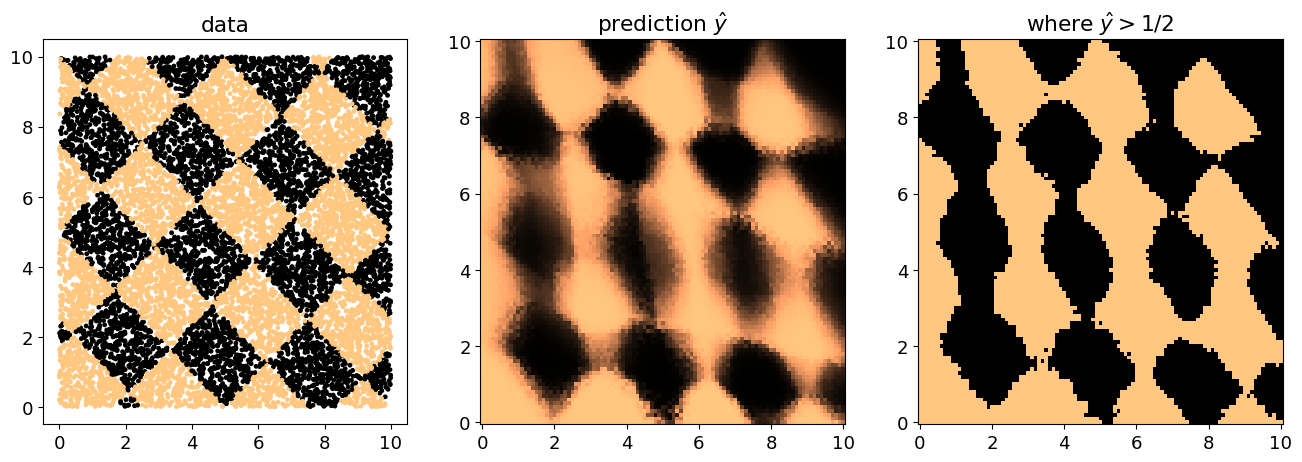

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [143]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

## Exercise: adjust for TYPE 4 - tune all parameters to obtain a good prediction

In [85]:
#to prevent overfitting: reduce model capacity, dropout, early stopping

In [ ]:
#to prevent underfitting: increase model capacity, less dropout, tune optimizer (learning rate)